### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t')
df

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
...,...,...,...,...,...,...,...,...,...
3102,1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3103,3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
3104,1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
3105,2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [5]:
for c in df.columns:
     if df[c].nunique() <= 10:
          print(c, ":", df[c].unique())

rating : [ 4  1 10  3  2  9  7  8  6  5]
effectiveness : ['Highly Effective' 'Marginally Effective' 'Ineffective'
 'Considerably Effective' 'Moderately Effective']
sideEffects : ['Mild Side Effects' 'Severe Side Effects' 'No Side Effects'
 'Extremely Severe Side Effects' 'Moderate Side Effects']


In [6]:
df = df[['Unnamed: 0', 'rating', 'effectiveness', 'sideEffects']]
df

,Unnamed: 0,rating,effectiveness,sideEffects
0,2202,4,Highly Effective,Mild Side Effects
1,3117,1,Highly Effective,Severe Side Effects
2,1146,10,Highly Effective,No Side Effects
3,3947,3,Marginally Effective,Mild Side Effects
4,1951,2,Marginally Effective,Severe Side Effects
...,...,...,...,...
3102,1039,10,Highly Effective,Mild Side Effects
3103,3281,1,Ineffective,Extremely Severe Side Effects
3104,1664,2,Marginally Effective,Moderate Side Effects
3105,2621,8,Considerably Effective,Mild Side Effects


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [7]:
map_effect = {
    'Ineffective': 1,
    'Marginally Effective': 2,
    'Moderately Effective': 3,
    'Considerably Effective': 4,    
    'Highly Effective': 5
}

In [8]:
map_side_ef = {
    'No Side Effects': 1,
    'Mild Side Effects': 2,
    'Moderate Side Effects': 3,
    'Severe Side Effects': 4,
    'Extremely Severe Side Effects': 5
}

In [9]:
df['effect'] = df['effectiveness'].map(map_effect)
df['sideEf'] = df['sideEffects'].map(map_side_ef)

C:\Users\detla\AppData\Local\Temp\ipykernel_3340\1628022146.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['effect'] = df['effectiveness'].map(map_effect)
C:\Users\detla\AppData\Local\Temp\ipykernel_3340\1628022146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sideEf'] = df['sideEffects'].map(map_side_ef)


In [10]:
df.drop(columns=['effectiveness', 'sideEffects'], inplace=True)
df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)

C:\Users\detla\AppData\Local\Temp\ipykernel_3340\3810157753.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['effectiveness', 'sideEffects'], inplace=True)
C:\Users\detla\AppData\Local\Temp\ipykernel_3340\3810157753.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)


In [11]:
df = df[['id', 'effect', 'sideEf', 'rating']]
df

,id,effect,sideEf,rating
0,2202,5,2,4
1,3117,5,4,1
2,1146,5,1,10
3,3947,2,2,3
4,1951,2,4,2
...,...,...,...,...
3102,1039,5,2,10
3103,3281,1,5,1
3104,1664,2,3,2
3105,2621,4,2,8


In [12]:
df.describe().round(4)

,id,effect,sideEf,rating
count,3107.0000,3107.0000,3107.0000,3107.0000
mean,2080.6070,3.9356,2.3048,7.0061
std,1187.9988,1.2305,1.1775,2.9376
min,0.0000,1.0000,1.0000,1.0000
25%,1062.5000,3.0000,1.0000,5.0000
50%,2092.0000,4.0000,2.0000,8.0000
75%,3092.5000,5.0000,3.0000,9.0000
max,4161.0000,5.0000,5.0000,10.0000


In [13]:
import seaborn as sns

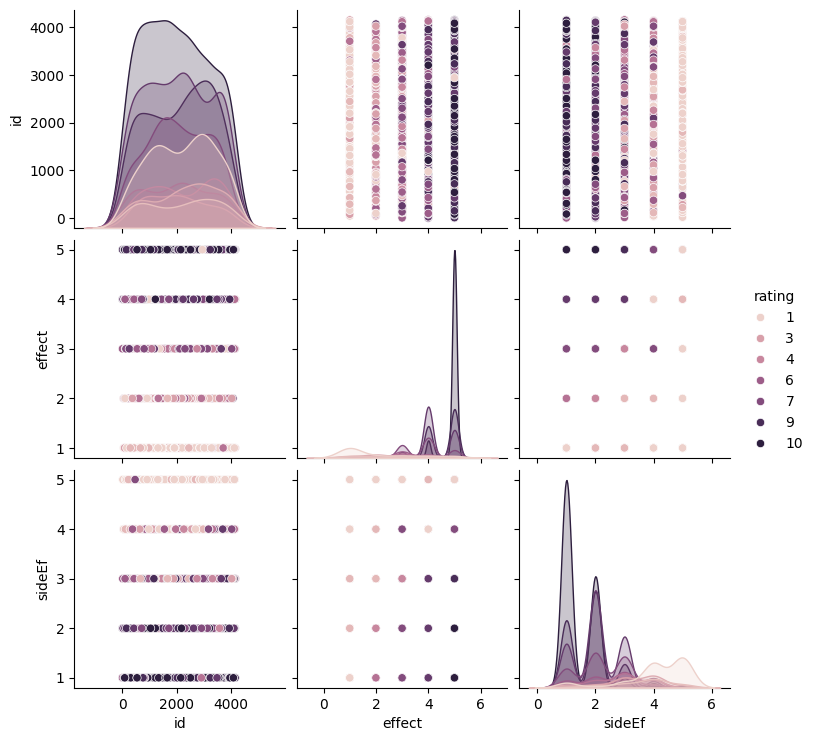

In [14]:
sns.pairplot(df, hue='rating');

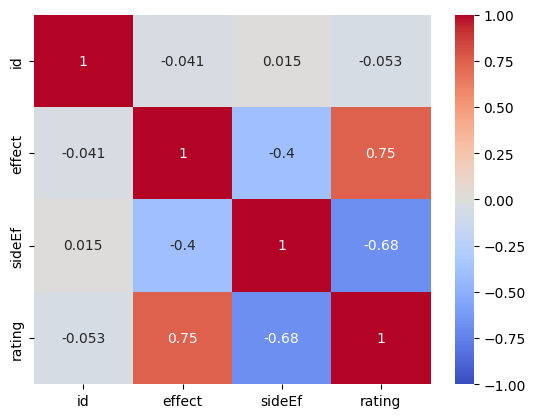

In [15]:
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm");

#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

#### Genera el K Means 

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [17]:
features_df = df[['effect', 'sideEf', 'rating']].copy()

In [18]:
features_scaled = StandardScaler().fit_transform(features_df)
features_scaled

array([[ 0.86510788, -0.25889536, -1.02349444],
       [ 0.86510788,  1.43991746, -2.04490682],
       [ 0.86510788, -1.10830176,  1.01933033],
       ...,
       [-1.57325636,  0.59051105, -1.70443603],
       [ 0.0523198 , -0.25889536,  0.33838874],
       [-0.76046828,  0.59051105, -1.02349444]], shape=(3107, 3))

In [19]:
silhouette_scores = []
K_range = range(2, 11)

In [ ]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_scaled)
    silhouette_avg = silhouette_score(features_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Para K={k}, el Silhouette Score es: {silhouette_avg:.4f}")


Para K=2, el Silhouette Score es: 0.5240
Para K=3, el Silhouette Score es: 0.4240
Para K=4, el Silhouette Score es: 0.3828
Para K=5, el Silhouette Score es: 0.3894
Para K=6, el Silhouette Score es: 0.4140
Para K=7, el Silhouette Score es: 0.4283
Para K=8, el Silhouette Score es: 0.4530
Para K=9, el Silhouette Score es: 0.4534
Para K=10, el Silhouette Score es: 0.5156


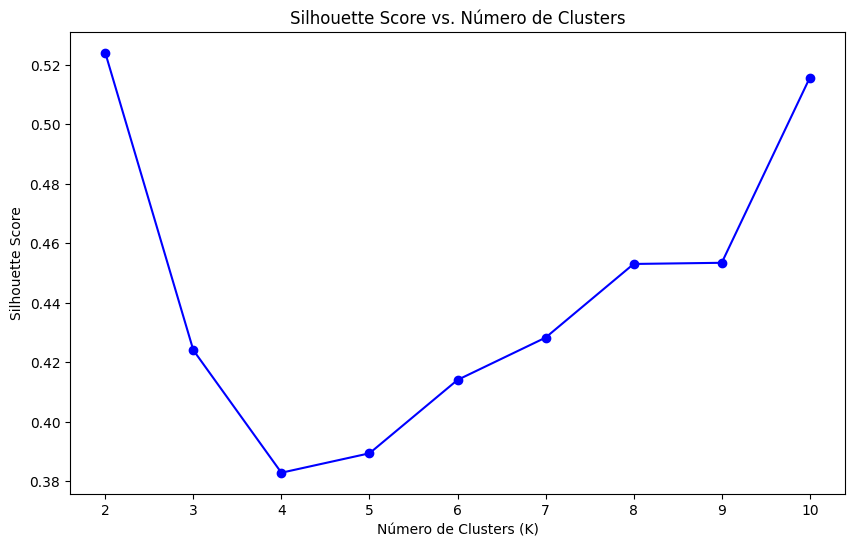

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Número de Clusters')
plt.xticks(K_range);

In [22]:
# Asumimos que la mejor K encontrada fue 3. CAMBIA ESTE VALOR si tu gráfica indicó otro.
mejor_k = 3 

# Entrenar el modelo final
kmeans_final = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(features_scaled)

# Ver las primeras filas con el cluster asignado
print(df.head())

     id  effect  sideEf  rating  cluster
0  2202       5       2       4        0
1  3117       5       4       1        0
2  1146       5       1      10        1
3  3947       2       2       3        2
4  1951       2       4       2        2


C:\Users\detla\AppData\Local\Temp\ipykernel_3340\1110259086.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = kmeans_final.fit_predict(features_scaled)


Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

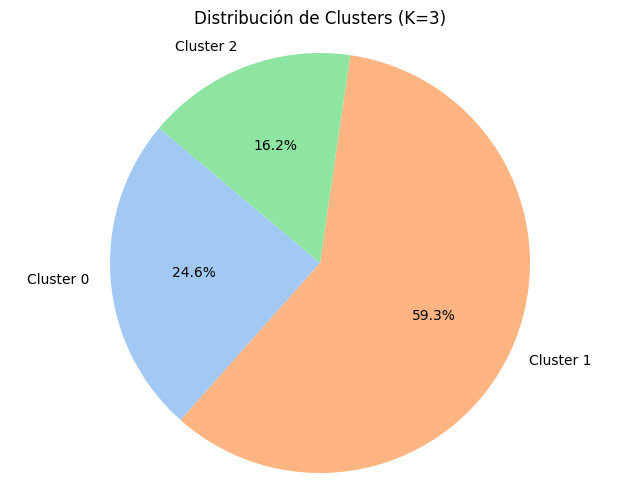


Medias de las variables por Cluster:
           effect    sideEf    rating
cluster                              
0        4.086501  3.340760  5.705111
1        4.493210  1.567083  8.865291
2        1.666004  3.433400  2.174950


In [23]:
# Contar cuántos elementos hay en cada cluster
cluster_counts = df['cluster'].value_counts().sort_index()

# Crear el Pie Plot
plt.figure(figsize=(8, 6))
# Usamos colores distintivos
colors = sns.color_palette('pastel')[0:mejor_k]
plt.pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index], 
        autopct='%1.1f%%', startangle=140, colors=colors)
plt.title(f'Distribución de Clusters (K={mejor_k})')
plt.axis('equal')  # Para que el pie chart sea un círculo perfecto
plt.show()

# Opcional: Ver las medias de cada cluster para entender qué representan
print("\nMedias de las variables por Cluster:")
print(df.groupby('cluster')[['effect', 'sideEf', 'rating']].mean())